# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Import Prerequis

In [2]:
import sys
import os
import subprocess

sys.path.append(os.path.abspath(os.path.join('..')))

### Compile Library C and generate JSON (make)

In [3]:
try:
    result = subprocess.run(
        "make -C ../libc clean && make -C ../libc",
        shell=True,
        capture_output=True,
        text=True
    )
    # print(result.stdout)

    if result.stderr:
        print(result.stderr)
    
    if result.returncode != 0:
        print(f"Build failed with exit code {result.returncode}")
        sys.exit(1)
    else:
        print("Build succeeded.")

except Exception as e:
    print(f"Build failed: {e}")
    sys.exit(1)

Build succeeded.


### Import Loader

In [4]:
from engine.interop.loader import Loader

# On doit restart kernel si on veut recharger la lib
try:
    Loader.loadLibrary(
        lib_name="libc",
        lib_folder="../libc",
        build_folder="../libc/build",
        specs_folder="../libc/specs",
        seed=None # ca va generer une seed aleatoire
    )

except Exception as e:
    if "already loaded" not in str(e).lower():
        raise RuntimeError(f"Failed to load library: {e}")
    
    print("Library already loaded, skipping.")

### Linear Model

In [5]:
from engine.interop.linearModel import LinearModel

In [106]:
def test_linear_model(
        X: np.ndarray,
        Y: np.ndarray,
        is_classification: bool,
        alpha: float = 0.05,
        epochs: int = 80
    ) -> None:
    
    X_input = X.ravel()
    Y_input = Y.ravel().ravel()
    Y_input = Y_input.astype(int) if is_classification else Y_input.astype(float)
    
    model = LinearModel.init_random(input_dim=len(X[0]))

    # Training
    model.train(
        dataset_inputs=X_input,
        dataset_expected_outputs=Y_input,
        alpha=alpha,
        epochs=epochs,
        is_classification=is_classification
    )

    # Prediction
    total = len(X)
    correct = 0
    incorrect_cases = []

    for i in range(len(X)):
        input_data = X[i].tolist()
        expected_output = Y[i]
        predicted_output = model.predict(input_data, is_classification=True)

        if predicted_output == expected_output:
            correct += 1
        else:
            incorrect_cases.append((i, expected_output, predicted_output))

    print(f"Total cases: {total}")
    print(f"Correct cases: {correct} ({correct/total*100:.2f}%)")
    print(f"Incorrect cases: {len(incorrect_cases)} ({len(incorrect_cases)/total*100:.2f}%)")

    if incorrect_cases:
        print("\nFirst incorrect cases (idx, expected, predicted):")
        for row in incorrect_cases[:10]:
            print(row)

# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [127]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      0,
      0
])

# tout mettre sur une ligne (avec bon type)

X_input = X.ravel()
Y_input = Y.ravel().astype(int).ravel()

In [128]:
print("#=== Linear Model ===#")
test_linear_model(X, Y, is_classification=True, alpha=0.05, epochs=800)

#=== Linear Model ===#
Total cases: 3
Correct cases: 3 (100.00%)
Incorrect cases: 0 (0.00%)


In [108]:
# plt.scatter(X[0, 0], X[0, 1], color='blue')
# plt.scatter(X[1:3,0], X[1:3,1], color='red')
# plt.show()
# plt.clf()

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [129]:
X = np.concatenate([
    np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
    np.random.random((50, 2)) * 0.9 + np.array([2, 2])
])
Y = np.concatenate([np.ones((50, 1)), np.zeros((50, 1))])

In [130]:
print("#=== Linear Model ===#")
test_linear_model(X, Y, is_classification=True, alpha=0.05, epochs=800)

#=== Linear Model ===#
Total cases: 100
Correct cases: 100 (100.00%)
Incorrect cases: 0 (0.00%)


In [101]:
# plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
# plt.scatter(X[50:100,0], X[50:100,1], color='red')
# plt.show()
# plt.clf()

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [131]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, 0, 0])

In [132]:
print("#=== Linear Model ===#")
test_linear_model(X, Y, is_classification=True, alpha=0.05, epochs=800)

#=== Linear Model ===#
Total cases: 4
Correct cases: 2 (50.00%)
Incorrect cases: 2 (50.00%)

First incorrect cases (idx, expected, predicted):
(0, np.int64(1), 0)
(1, np.int64(1), 0)


In [115]:
# plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
# plt.scatter(X[2:4,0], X[2:4,1], color='red')
# plt.show()
# plt.clf()

























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [134]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else 0 for p in X])

In [135]:
print("#=== Linear Model ===#")
test_linear_model(X, Y, is_classification=True, alpha=0.05, epochs=800)

#=== Linear Model ===#
Total cases: 500
Correct cases: 256 (51.20%)
Incorrect cases: 244 (48.80%)

First incorrect cases (idx, expected, predicted):
(1, np.int64(1), 0)
(2, np.int64(1), 0)
(5, np.int64(1), 0)
(7, np.int64(1), 0)
(8, np.int64(1), 0)
(10, np.int64(1), 0)
(11, np.int64(1), 0)
(13, np.int64(1), 0)
(14, np.int64(1), 0)
(23, np.int64(1), 0)


In [ ]:
# plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
# plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
# plt.show()
# plt.clf()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [145]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

In [143]:
print("#=== Linear Model ===#")
test_linear_model(X, Y, is_classification=True, alpha=0.05, epochs=800)

#=== Linear Model ===#


ValueError: LinearModel.train(): `dataset_expected_outputs` length must equal dataset_size (500).

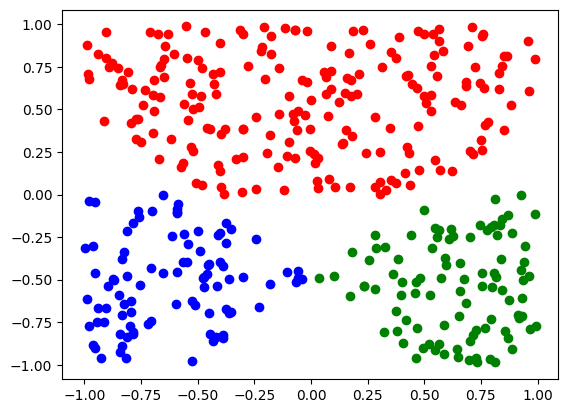

<Figure size 640x480 with 0 Axes>

In [141]:
X = X[[not np.all(arr == [0, 0, 0]) for arr in Y]]
Y = Y[[not np.all(arr == [0, 0, 0]) for arr in Y]]

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [ ]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

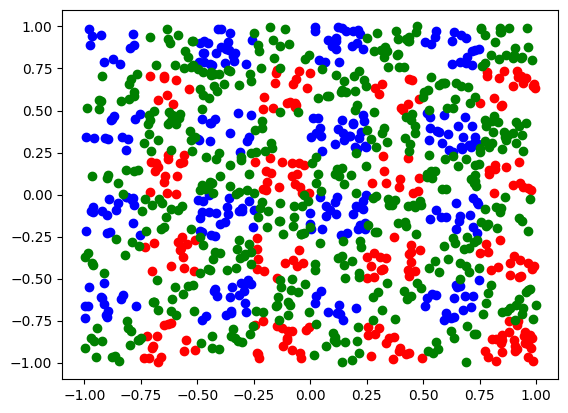

<Figure size 640x480 with 0 Axes>

In [20]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [21]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

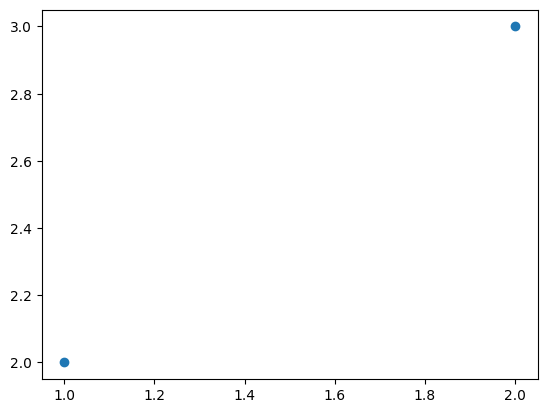

<Figure size 640x480 with 0 Axes>

In [22]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [23]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

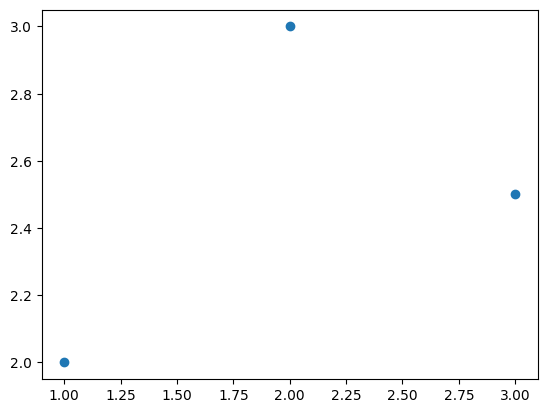

<Figure size 640x480 with 0 Axes>

In [24]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [25]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

In [26]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [27]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

In [28]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [ ]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

In [30]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>